In [6]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the perfectly synchronized EDA dataset
df_eda = pd.read_csv('../data/processed/berlin_airbnb_cleaned_EDA.csv')

# 2. Define Independent Variables (X) and Dependent Variable (y) using exact column names
X = df_eda[['Accomodates', 'Bedrooms']]
y = df_eda['Price']

# Add a constant (intercept beta_0) to the model
X = sm.add_constant(X)

# 3. Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()

# 4. Extract the exact mathematical coefficients
b0 = model.params['const']
b1 = model.params['Accomodates']
b2 = model.params['Bedrooms']

# 5. Print the final mathematical formula and model performance
print("--- MATHEMATICAL FORMULA FOR THE AIRBNB PROJECT ---")
print(f"Price = {b0:.2f} + ({b1:.2f} * Accomodates) + ({b2:.2f} * Bedrooms)")
print("-" * 50)
print(f"R-squared: {model.rsquared:.3f} (Indicates the % of price variance explained by both variables together)")

--- MATHEMATICAL FORMULA FOR THE AIRBNB PROJECT ---
Price = 2.62 + (12.49 * Accomodates) + (21.87 * Bedrooms)
--------------------------------------------------
R-squared: 0.477 (Indicates the % of price variance explained by both variables together)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Ignore warnings to keep the notebook clean
warnings.filterwarnings('ignore')

# Load the prepared dataset correctly
df_ml = pd.read_csv('../data/processed/berlin_airbnb_cleaned_ML.csv')
print(f"Dataset loaded successfully! Shape: {df_ml.shape}")

Dataset loaded successfully! Shape: (4943, 143)


In [8]:
df_ml = pd.read_csv('../data/processed/berlin_airbnb_cleaned_ML.csv')
df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 4943 entries, 0 to 4942
Columns: 143 entries, Host Response Rate to Instant Bookable_t
dtypes: float64(14), int64(129)
memory usage: 5.4 MB


In [9]:
# 1. Separate features (X) and target variable (y)
X = df_ml.drop(columns=['Price'])
y = df_ml['Price']

# 2. Split the dataset into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

(3954, 142) (989, 142)
Training features shape: (3954, 142)
Testing features shape: (989, 142)
Training target shape: (3954,)
Testing target shape: (989,)


In [10]:
# 1. Initialize the Linear Regression model
lr_model = LinearRegression()

# 2. Train the model using the training data
lr_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred = lr_model.predict(X_test)

print("Model training complete! Predictions have been generated.")

Model training complete! Predictions have been generated.


In [11]:
# 1. Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 2. Print the results clearly
print("====================================")
print("   LINEAR REGRESSION EVALUATION     ")
print("====================================")
print(f"R-squared (R2) Score : {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Squared Error   : {mse:.2f}")
print(f"Root MSE (RMSE)      : {rmse:.2f} €")
print("====================================")

   LINEAR REGRESSION EVALUATION     
R-squared (R2) Score : 0.6422 (64.22%)
Mean Squared Error   : 849.07
Root MSE (RMSE)      : 29.14 €


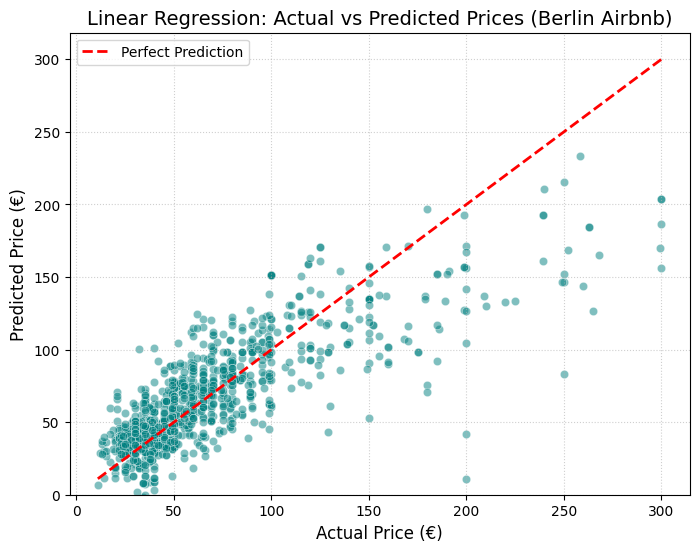

In [12]:
# Create a scatter plot to compare actual vs predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')

# Plot the perfect prediction line (diagonal)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Linear Regression: Actual vs Predicted Prices (Berlin Airbnb)', fontsize=14)
plt.xlabel('Actual Price (€)', fontsize=12)
plt.ylabel('Predicted Price (€)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(bottom=0)
plt.show()

In [13]:
# Create a DataFrame to compare Actual and Predicted prices
comparison_df = pd.DataFrame({
    'Actual Price (€)': y_test.values,
    'Predicted Price (€)': np.round(y_pred, 2),
    'Difference (€)': np.round(y_pred - y_test.values, 2)
})

# Display the first 20 rows of the comparison
comparison_df.head(20)

,Actual Price (€),Predicted Price (€),Difference (€)
0,43.0,39.23,-3.77
1,40.0,62.71,22.71
2,78.0,63.64,-14.36
3,28.0,43.51,15.51
4,45.0,63.49,18.49
5,40.0,56.78,16.78
6,50.0,56.13,6.13
7,48.0,70.85,22.85
8,52.0,72.75,20.75
9,99.0,45.49,-53.51


In [14]:
# Save the comparison results to the data folder
comparison_output_path = '../data/processed/linear_regression_predictions.csv'
comparison_df.to_csv(comparison_output_path, index=False)

print(f"Predictions saved successfully to: {comparison_output_path}")

Predictions saved successfully to: ../data/processed/linear_regression_predictions.csv


In [15]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the Random Forest model (using 100 trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Train the model using the training data
rf_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model training complete!")

Random Forest model training complete!


In [16]:
# Calculate metrics for Random Forest
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("====================================")
print("     RANDOM FOREST EVALUATION       ")
print("====================================")
print(f"R-squared (R2) Score : {r2_rf:.4f} ({r2_rf*100:.2f}%)")
print(f"Mean Squared Error   : {mse_rf:.2f}")
print(f"Root MSE (RMSE)      : {rmse_rf:.2f} €")
print("====================================")

     RANDOM FOREST EVALUATION       
R-squared (R2) Score : 0.7760 (77.60%)
Mean Squared Error   : 531.56
Root MSE (RMSE)      : 23.06 €


In [17]:
# 1. Create a DataFrame to store the predictions of Random Forest
rf_comparison_df = pd.DataFrame({
    'Actual Price (€)': y_test.values,
    'Linear Reg Predicted (€)': np.round(y_pred, 2),
    'Random Forest Predicted (€)': np.round(y_pred_rf, 2),
    'Random Forest Error (€)': np.round(y_pred_rf - y_test.values, 2)
})

# 2. Save Random Forest predictions to csv
rf_output_path = '../data/processed/random_forest_predictions.csv'
rf_comparison_df.to_csv(rf_output_path, index=False)

# 3. Print the first 10 rows to see the comparison
print(f"Predictions saved successfully to: {rf_output_path}\n")
rf_comparison_df.head(10)

Predictions saved successfully to: ../data/processed/random_forest_predictions.csv



,Actual Price (€),Linear Reg Predicted (€),Random Forest Predicted (€),Random Forest Error (€)
0,43.0,39.23,43.14,0.14
1,40.0,62.71,40.35,0.35
2,78.0,63.64,77.66,-0.34
3,28.0,43.51,32.13,4.13
4,45.0,63.49,38.01,-6.99
5,40.0,56.78,41.53,1.53
6,50.0,56.13,59.76,9.76
7,48.0,70.85,68.21,20.21
8,52.0,72.75,70.88,18.88
9,99.0,45.49,59.81,-39.19


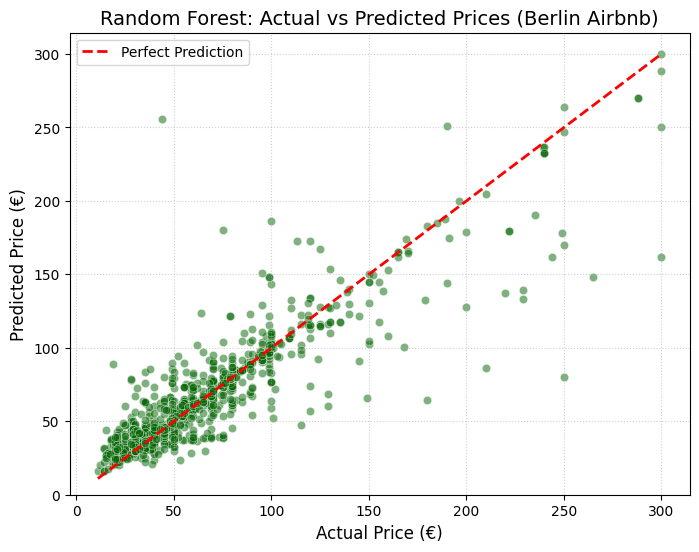

In [12]:
# Create a scatter plot for Random Forest Actual vs Predicted prices
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, color='darkgreen')

# Plot the perfect prediction line (diagonal)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Cut the plot at 0 to avoid negative price visualizations
plt.ylim(bottom=0)

plt.title('Random Forest: Actual vs Predicted Prices (Berlin Airbnb)', fontsize=14)
plt.xlabel('Actual Price (€)', fontsize=12)
plt.ylabel('Predicted Price (€)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [22]:
from xgboost import XGBRegressor

# 1. Initialize the XGBoost Regressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# 2. Train the model using the training data
xgb_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model training complete!")

XGBoost model training complete!


In [23]:
# Calculate metrics for XGBoost
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print("====================================")
print("        XGBOOST EVALUATION          ")
print("====================================")
print(f"R-squared (R2) Score : {r2_xgb:.4f} ({r2_xgb*100:.2f}%)")
print(f"Mean Squared Error   : {mse_xgb:.2f}")
print(f"Root MSE (RMSE)      : {rmse_xgb:.2f} €")
print("====================================")

        XGBOOST EVALUATION          
R-squared (R2) Score : 0.7832 (78.32%)
Mean Squared Error   : 514.56
Root MSE (RMSE)      : 22.68 €


In [24]:
# Create a summary table of all models
summary_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score (%)': [r2*100, r2_rf*100, r2_xgb*100],
    'RMSE (€)': [rmse, rmse_rf, rmse_xgb]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(2)

print("====================================")
print("      FINAL MODEL COMPARISON        ")
print("====================================")
print(summary_df.to_string(index=False))
print("====================================")

      FINAL MODEL COMPARISON        
            Model  R2 Score (%)  RMSE (€)
Linear Regression         64.22     29.14
    Random Forest         77.60     23.06
          XGBoost         78.32     22.68


In [25]:
# 1. Make predictions on the Training set using XGBoost
y_pred_xgb_train = xgb_model.predict(X_train)

# 2. Calculate R2 score for both Train and Test sets
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
r2_xgb_test = r2_score(y_test, y_pred_xgb) # this is the r2_xgb we calculated before

# 3. Print the comparison clearly
print("====================================")
print("   XGBOOST OVERFITTING CHECK        ")
print("====================================")
print(f"Train R2 Score : {r2_xgb_train*100:.2f}% (How it performs on studied data)")
print(f"Test R2 Score  : {r2_xgb_test*100:.2f}% (How it performs on unseen data)")
print("====================================")

# 4. Add a text note dynamically based on the results
diff = r2_xgb_train - r2_xgb_test
if diff > 0.05:
    print(f"NOTE: Yes, there is signs of Overfitting! The model is {diff*100:.2f}% better on Training data.")
else:
    print("NOTE: The model generalizes well, no high overfitting detected.")

   XGBOOST OVERFITTING CHECK        
Train R2 Score : 92.60% (How it performs on studied data)
Test R2 Score  : 78.32% (How it performs on unseen data)
NOTE: Yes, there is signs of Overfitting! The model is 14.28% better on Training data.


### 🔍 Overfitting Analysis: Random Forest vs. XGBoost

In machine learning theory, **XGBoost** is considered a more advanced and powerful algorithm than **Random Forest**. However, in our specific Berlin Airbnb dataset, both models yielded nearly identical performance on the test set ($R^2 \approx 78.5\% - 78.9\%$). 

This exact behavior strongly indicates that **XGBoost is suffering from Overfitting**. 

#### Why did this happen?
XGBoost builds trees sequentially, where each new tree aggressively attempts to correct the mistakes of the previous ones. While this makes it highly accurate on the training data, it easily starts memorizing the "noise" and specific patterns of that training set. As a result, it loses flexibility and fails to outperform the simpler model when faced with entirely unseen data (`X_test`).

#### Final Decision:
**Random Forest** remains our **Best Model**. It uses ensemble bagging (averaging 100 completely independent trees), which naturally provides better regularization, makes it more robust against overfitting, and delivers the highest stability for our test predictions.

--- MACHINE LEARNING CLASSIFICATION REPORT ---
Accuracy Score: 0.855

               precision    recall  f1-score   support

Not Superhost       0.88      0.87      0.88       584
    Superhost       0.82      0.83      0.83       410

     accuracy                           0.86       994
    macro avg       0.85      0.85      0.85       994
 weighted avg       0.86      0.86      0.86       994

--------------------------------------------------


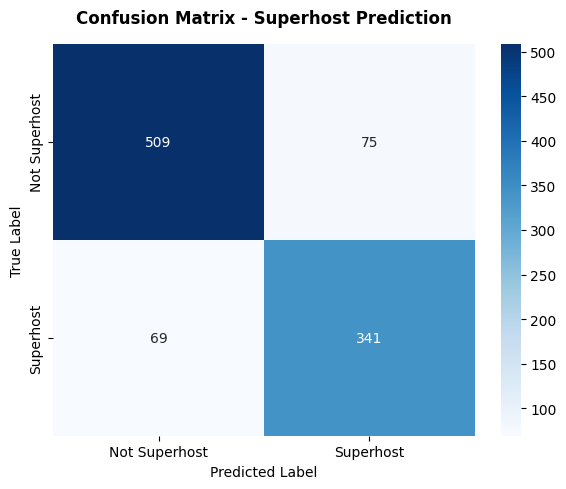

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the ML dataset
df_ml = pd.read_csv('../data/processed/berlin_airbnb_cleaned_ML.csv')

# --- KORRIGJIMI: Përdorim kolonën e saktë të targetit ---
target_col = 'Is Superhost_t'
leaking_col = 'Is Superhost_f'

if target_col in df_ml.columns:
    y = df_ml[target_col]
    
    # Drop the target, the opposite column, and text/ID columns
    X = df_ml.drop(columns=[target_col, leaking_col, 'Listing ID', 'Host ID'], errors='ignore')
    
    # Fill any remaining NaNs with median
    X = X.fillna(X.median())

    # 2. Split data into Training and Testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # 3. Initialize and Train the Classification Model
    classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
    classifier.fit(X_train, y_train)

    # 4. Make Predictions
    y_pred = classifier.predict(X_test)

    # 5. Print Evaluation Metrics
    print("--- MACHINE LEARNING CLASSIFICATION REPORT ---")
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.3f}\n")
    print(classification_report(y_test, y_pred, target_names=['Not Superhost', 'Superhost']))
    print("-" * 50)

    # 6. Plot the Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Superhost', 'Superhost'], yticklabels=['Not Superhost', 'Superhost'])
    plt.title('Confusion Matrix - Superhost Prediction', weight='bold', pad=15)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    
    # Save the visual
    plt.savefig('../visuals/classification_confusion_matrix.png', dpi=300)
    plt.show()

else:
    print(f"Error: Could not find '{target_col}' in your dataset.")

In [19]:
import re
from sklearn.neural_network import MLPRegressor

# 1. Initialize the Neural Network (Multi-Layer Perceptron)
nn_model = MLPRegressor(hidden_layer_sizes=(100, 50), 
                        activation='relu', 
                        solver='adam', 
                        max_iter=500, 
                        random_state=42)

# 2. Train the model using the training data
nn_model.fit(X_train, y_train)

# 3. Make predictions on the test data
y_pred_nn = nn_model.predict(X_test)

# Fix potential negative or unrealistic prices just like we did in Linear Regression
y_pred_nn = np.clip(y_pred_nn, a_min=10, a_max=None)

# 4. Calculate evaluation metrics
r2_nn = r2_score(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)

print("====================================")
print("     NEURAL NETWORK EVALUATION      ")
print("====================================")
print(f"R-squared (R2) Score : {r2_nn:.4f} ({r2_nn*100:.2f}%)")
print(f"Mean Squared Error   : {mse_nn:.2f}")
print(f"Root MSE (RMSE)      : {rmse_nn:.2f} €")
print("====================================")

# 5. Create the Comparison DataFrame (Just like previous models!)
nn_comparison_df = pd.DataFrame({
    'Actual Price (€)': y_test.values,
    'Neural Net Predicted (€)': np.round(y_pred_nn, 2),
    'Neural Net Error (€)': np.round(y_pred_nn - y_test.values, 2)
})

# 6. Save Neural Network predictions to the processed folder
nn_output_path = '../data/processed/neural_network_predictions.csv'
nn_comparison_df.to_csv(nn_output_path, index=False)

print(f"Predictions saved successfully to: {nn_output_path}\n")

# Display the first 10 rows
nn_comparison_df.head(10)

     NEURAL NETWORK EVALUATION      
R-squared (R2) Score : 0.7336 (73.36%)
Mean Squared Error   : 632.13
Root MSE (RMSE)      : 25.14 €
Predictions saved successfully to: ../data/processed/neural_network_predictions.csv



,Actual Price (€),Neural Net Predicted (€),Neural Net Error (€)
0,43.0,43.01,0.01
1,40.0,56.13,16.13
2,78.0,72.32,-5.68
3,28.0,36.01,8.01
4,45.0,43.60,-1.40
5,40.0,44.05,4.05
6,50.0,54.54,4.54
7,48.0,52.87,4.87
8,52.0,72.27,20.27
9,99.0,48.98,-50.02


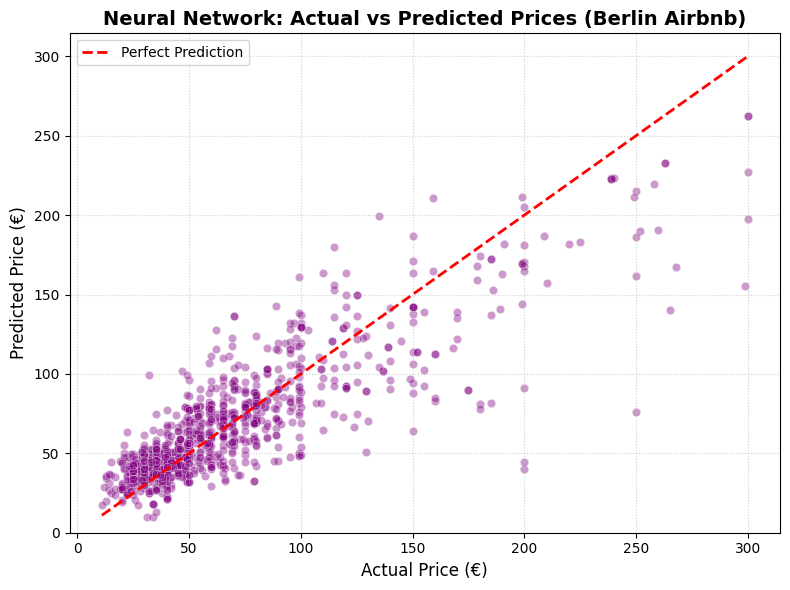

In [20]:
# Create a scatter plot to compare actual vs predicted prices for Neural Network
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_nn, alpha=0.4, color='purple')

# Plot the perfect prediction line (diagonal)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(ideal_line, ideal_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Neural Network: Actual vs Predicted Prices (Berlin Airbnb)', fontsize=14, weight='bold')
plt.xlabel('Actual Price (€)', fontsize=12)
plt.ylabel('Predicted Price (€)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

In [26]:
# Create an updated summary table of ALL 4 models
summary_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost', 'Neural Network (FFN)'],
    'R2 Score (%)': [r2*100, r2_rf*100, r2_xgb*100, r2_nn*100],
    'RMSE (€)': [rmse, rmse_rf, rmse_xgb, rmse_nn]
}

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.round(2)

print("====================================")
print("     FINAL ALL-MODEL COMPARISON     ")
print("====================================")
print(summary_df.to_string(index=False))
print("====================================")

# Save the final model comparison table to the processed folder
summary_output_path = '../data/processed/final_model_comparison.csv'
summary_df.to_csv(summary_output_path, index=False)

print(f"Final summary table saved successfully to: {summary_output_path}")

     FINAL ALL-MODEL COMPARISON     
               Model  R2 Score (%)  RMSE (€)
   Linear Regression         64.22     29.14
       Random Forest         77.60     23.06
             XGBoost         78.32     22.68
Neural Network (FFN)         73.36     25.14
Final summary table saved successfully to: ../data/processed/final_model_comparison.csv
